# Results Aggregation — Cooperative Lasso vs DAIF (Onsager)

Compares prediction error of:
- **DAIF**: AMP pipeline with CKA-based modality clustering (linear predictor on denoised latent factors)
- **Coop. Lasso**: Cooperative regularized linear regression (Ding & Tibshirani 2021, eq. 17),
  operating directly on raw modality matrices with a pairwise agreement penalty

Fixed DGP: 3 modalities, $\gamma = [0.25, 0.8, 3.0]$, $r = [2, 3, 2]$, linear response.
Varies $n \in \{1000, 1500, 2000\}$, 50 seeds each.

**Table format:** `mean(se)`. Bold = lower mean prediction error per column.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Latex

# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------
RESULTS_DIR    = "../Results/coop_vs_daif_onsager"
os.makedirs(RESULTS_DIR, exist_ok=True)
PLOTS_DIR      = "../Plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
OUTPUT_CSV     = "output_coop_vs_daif_onsager.csv"
OUTPUT_TEX     = "results_table_coop_vs_daif_onsager.tex"

N_VALUES   = [1000, 1500, 2000]
NUM_TRIALS = 50

METHOD_LABELS = {
    "daif":       "DAIF",
    "coop_lasso": "Coop. Lasso",
}

In [2]:
# ---------------------------------------------------------------
# Load all partial results
# ---------------------------------------------------------------
pattern = os.path.join(RESULTS_DIR, "partial_result_*.csv")
files   = glob.glob(pattern)

if not files:
    raise FileNotFoundError(f"No partial result files found in {RESULTS_DIR}")

print(f"Found {len(files)} partial result files.")
df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Total rows: {len(df_all)}")
df_all.head()

Found 150 partial result files.
Total rows: 300


,n,seed,method,pred_error,best_rho,best_lambda
0,2000,42,daif,0.021697,NaN,NaN
1,2000,42,coop_lasso,0.342250,0.0,25.644472
2,1500,3,daif,0.027214,NaN,NaN
3,1500,3,coop_lasso,0.282654,0.0,25.959383
4,1000,29,daif,0.045257,NaN,NaN


In [3]:
# ---------------------------------------------------------------
# Completeness check
# ---------------------------------------------------------------
print("Completeness check:")
for n in N_VALUES:
    for method in METHOD_LABELS:
        df_nm   = df_all[(df_all["n"] == n) & (df_all["method"] == method)]
        n_seeds = df_nm["seed"].nunique()
        status  = "OK" if n_seeds >= NUM_TRIALS else f"WARNING: only {n_seeds}/{NUM_TRIALS} seeds"
        print(f"  n={n:5d}  method={method:12s}: {n_seeds} seeds — {status}")

Completeness check:
  n= 1000  method=daif        : 50 seeds — OK
  n= 1000  method=coop_lasso  : 50 seeds — OK
  n= 1500  method=daif        : 50 seeds — OK
  n= 1500  method=coop_lasso  : 50 seeds — OK
  n= 2000  method=daif        : 50 seeds — OK
  n= 2000  method=coop_lasso  : 50 seeds — OK


In [4]:
# ---------------------------------------------------------------
# Aggregate: mean and SE of prediction error per (n, method)
# summary[n][method] = {'mean': float, 'se': float}
# ---------------------------------------------------------------
summary = {}
for n in sorted(df_all["n"].unique()):
    summary[n] = {}
    for method in METHOD_LABELS:
        df_nm    = df_all[(df_all["n"] == n) & (df_all["method"] == method)]
        n_trials = len(df_nm)
        if n_trials == 0:
            summary[n][method] = {"mean": np.nan, "se": np.nan}
            continue
        mean = df_nm["pred_error"].mean()
        se   = df_nm["pred_error"].std() / np.sqrt(n_trials)
        summary[n][method] = {"mean": mean, "se": se}

# Sanity print
print("Prediction error summary:")
for n, meths in summary.items():
    print(f"  n={n}:")
    for method, vals in meths.items():
        print(f"    {METHOD_LABELS[method]:15s}: mean={vals['mean']:.5f}  se={vals['se']:.5f}")

Prediction error summary:
  n=1000:
    DAIF           : mean=0.04145  se=0.00353
    Coop. Lasso    : mean=0.80509  se=0.09983
  n=1500:
    DAIF           : mean=0.02758  se=0.00172
    Coop. Lasso    : mean=0.90925  se=0.09069
  n=2000:
    DAIF           : mean=0.02517  se=0.00102
    Coop. Lasso    : mean=0.73384  se=0.08698


In [5]:
# ---------------------------------------------------------------
# Selected rho distribution for Cooperative Lasso
# ---------------------------------------------------------------
df_coop = df_all[df_all["method"] == "coop_lasso"].copy()
if "best_rho" in df_coop.columns:
    print("Selected rho distribution by n:")
    print(df_coop.groupby("n")["best_rho"].value_counts().unstack(fill_value=0))

Selected rho distribution by n:
best_rho  0.0
n            
1000       50
1500       50
2000       50


In [6]:
# ---------------------------------------------------------------
# Save flat summary CSV
# ---------------------------------------------------------------
rows = []
for n, meths in summary.items():
    for method, vals in meths.items():
        rows.append({"n": n, "method": METHOD_LABELS[method],
                     "pred_error_mean": vals["mean"],
                     "pred_error_se":   vals["se"]})

df_summary = pd.DataFrame(rows)
df_summary.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {OUTPUT_CSV}")
df_summary

Saved output_coop_vs_daif_onsager.csv


,n,method,pred_error_mean,pred_error_se
0,1000,DAIF,0.041453,0.003529
1,1000,Coop. Lasso,0.805090,0.099835
2,1500,DAIF,0.027581,0.001718
3,1500,Coop. Lasso,0.909247,0.090687
4,2000,DAIF,0.025173,0.001022
5,2000,Coop. Lasso,0.733842,0.086978


In [7]:
# ---------------------------------------------------------------
# Build LaTeX table
# Rows: DAIF, Coop. Lasso
# Columns: n = 1000, 1500, 2000
# ---------------------------------------------------------------

def build_latex_table(summary, n_values, method_labels):
    n_cols   = len(n_values)
    col_spec = 'l' + 'r' * n_cols
    col_headers = ' & '.join([f'$n = {n}$' for n in n_values])

    # Best (lowest) mean per n column
    col_mins = [
        min(summary[n][m]['mean'] for m in method_labels
            if not np.isnan(summary[n][m]['mean']))
        for n in n_values
    ]

    lines = []
    lines.append(r'\begin{table}[ht]')
    lines.append(r'\centering')
    lines.append(r'\begin{tabular}{' + col_spec + '}')
    lines.append(r'\toprule')
    lines.append(f'Method & {col_headers} \\\\')
    lines.append(r'\midrule')

    for method, label in method_labels.items():
        cells = []
        for col, n in enumerate(n_values):
            mean = summary[n][method]['mean']
            se   = summary[n][method]['se']
            if np.isnan(mean):
                cells.append('---')
                continue
            cell = f'{mean:.4f}({se:.4f})'
            if abs(mean - col_mins[col]) < 1e-9:
                cell = r'\textbf{' + cell + '}'
            cells.append(cell)
        lines.append(label + ' & ' + ' & '.join(cells) + r' \\')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(
        r'\caption{Test-set mean squared prediction error (mean with standard error '
        r'in parentheses) for DAIF and Cooperative Lasso across sample sizes. '
        r'\textbf{DAIF}: AMP + CKA clustering, linear predictor on denoised latent factors. '
        r'\textbf{Coop.\ Lasso}: cooperative regularized linear regression on raw modality '
        r'matrices (Ding \& Tibshirani 2021); $\rho$ and $\lambda$ selected by '
        r'validation-set search. Bold = lower mean error per column.}'
    )
    lines.append(r'\label{tab:coop_vs_daif_onsager}')
    lines.append(r'\end{table}')

    return '\n'.join(lines)


n_values_present = sorted(summary.keys())
latex_str = build_latex_table(summary, n_values_present, METHOD_LABELS)
print(latex_str)

\begin{table}[ht]
\centering
\begin{tabular}{lrrr}
\toprule
Method & $n = 1000$ & $n = 1500$ & $n = 2000$ \\
\midrule
DAIF & \textbf{0.0415(0.0035)} & \textbf{0.0276(0.0017)} & \textbf{0.0252(0.0010)} \\
Coop. Lasso & 0.8051(0.0998) & 0.9092(0.0907) & 0.7338(0.0870) \\
\bottomrule
\end{tabular}
\caption{Test-set mean squared prediction error (mean with standard error in parentheses) for DAIF and Cooperative Lasso across sample sizes. \textbf{DAIF}: AMP + CKA clustering, linear predictor on denoised latent factors. \textbf{Coop.\ Lasso}: cooperative regularized linear regression on raw modality matrices (Ding \& Tibshirani 2021); $\rho$ and $\lambda$ selected by validation-set search. Bold = lower mean error per column.}
\label{tab:coop_vs_daif_onsager}
\end{table}


In [8]:
display(Latex(latex_str))

<IPython.core.display.Latex object>

In [9]:
with open(OUTPUT_TEX, "w") as f:
    f.write(latex_str)
print(f"Saved {OUTPUT_TEX}")

Saved results_table_coop_vs_daif_onsager.tex


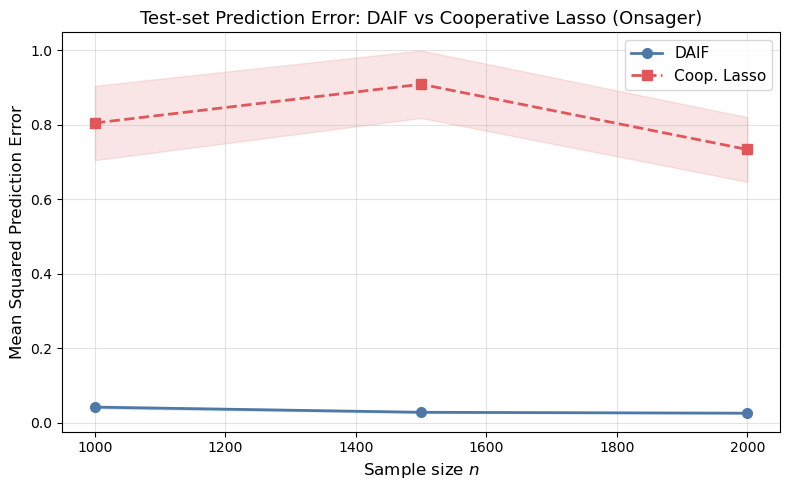

Saved ../Plots/coop_vs_daif_pred_error_onsager.png


In [10]:
# ---------------------------------------------------------------
# Plot — prediction error vs n, both methods
# ---------------------------------------------------------------
METHOD_STYLES = {
    "daif":       {"marker": "o", "linestyle": "-",  "color": "#4E79A7", "label": "DAIF"},
    "coop_lasso": {"marker": "s", "linestyle": "--", "color": "#E15759", "label": "Coop. Lasso"},
}

fig, ax = plt.subplots(figsize=(8, 5))

for method, style in METHOD_STYLES.items():
    means = np.array([summary[n][method]['mean'] for n in n_values_present])
    ses   = np.array([summary[n][method]['se']   for n in n_values_present])
    ax.plot(n_values_present, means,
            marker=style['marker'], linestyle=style['linestyle'],
            color=style['color'], linewidth=2, markersize=7, label=style['label'])
    ax.fill_between(n_values_present, means - ses, means + ses,
                    color=style['color'], alpha=0.15)

ax.set_title('Test-set Prediction Error: DAIF vs Cooperative Lasso (Onsager)', fontsize=13)
ax.set_xlabel('Sample size $n$', fontsize=12)
ax.set_ylabel('Mean Squared Prediction Error', fontsize=12)
ax.grid(True, alpha=0.35)
ax.legend(fontsize=11)
fig.tight_layout()

path = os.path.join(PLOTS_DIR, 'coop_vs_daif_pred_error_onsager.png')
fig.savefig(path, dpi=150)
plt.show()
print(f'Saved {path}')